# Fig 06: Normalized model-obs SST misfit for the N-case

In [1]:
import os
os.chdir('/glade/work/fengzhu/Projects/paper-OnlinePDA_CESM/notebooks')
import numpy as np
import pandas as pd
import xarray as xr
import x4c
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
import datetime
print(f'Last update: {datetime.date.today()}')

Last update: 2026-06-12


## Load Data

In [ ]:
case = 'ppe_490ppm'
tags = ['1xCO2', '350ppm', '400ppm', '2xCO2']
vns  = ['SST']

fd = {vn: {} for vn in vns}
for vn in vns:
    da = {}
    for tag in tags + ['490ppm']:
        da[tag] = xr.open_dataarray(f'../sims/da_{vn}_{tag}.nc').mean('time')
    fd[vn]['Truth'] = da['490ppm']
    fd[vn]['Prior'] = (da['1xCO2'] + da['350ppm'] + da['400ppm'] + da['2xCO2']) / 4

In [3]:
recon = xr.open_dataset(f'../recons/recon_Plio490ppm_R4.00_loc10000.nc')

fd['SST']['Offline'] = recon['TEMP'].isel(z_t=0).mean(('time', 'ens'))
fd['SST']['Offline'].name = 'SST'

In [4]:
for vn in vns:
    da = {}
    for tag in tags:
        da[tag] = xr.open_dataarray(f'../sims/da_{vn}_{tag}_{case}_fixed.nc').mean('time')
    fd[vn]['Online'] = (da['1xCO2'] + da['350ppm'] + da['400ppm'] + da['2xCO2']) / 4


In [5]:
df = pd.read_json(f'../pseudoproxy/ppe_Plio490ppm_obs_SST_R4.00.json')
ms = 20

## Plot

In [6]:
obs_value = df['value'].apply(lambda v: np.asarray(v).squeeze()).to_numpy(dtype=float)
obs_lat = df['lat'].to_numpy()
obs_lon = np.mod(df['lon'].to_numpy(), 360)
obs_sigma = np.sqrt(float(df['R'].iloc[0]))

def sample_at_obs(da):
    return np.array([
        np.asarray(
            da.x.nearest2d(
                lat=lat,
                lon=lon,
                lat_dim='nlat',
                lon_dim='nlon',
                lat_coord='TLAT',
                lon_coord='TLONG',
            )
        ).squeeze()
        for lat, lon in zip(obs_lat, obs_lon)
    ], dtype=float)

misfits = {
    label: (sample_at_obs(fd['SST'][label]) - obs_value) / obs_sigma
    for label in ['Truth', 'Prior', 'Offline', 'Online']
}

finite = np.concatenate([vals[np.isfinite(vals)] for vals in misfits.values()])
x_min, x_max = finite.min(), finite.max()
x_grid = np.linspace(x_min, x_max, 300)
colors = {
    'Truth': 'k',
    'Prior': 'tab:blue',
    'Offline': 'tab:green',
    'Online': 'tab:orange',
}

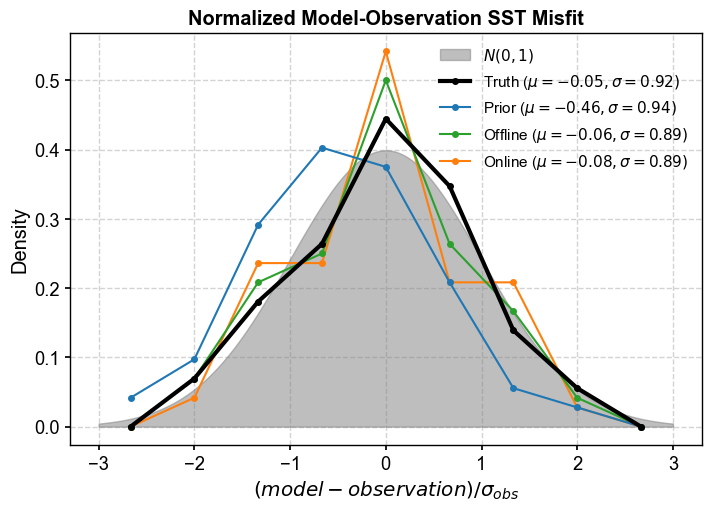

Figure saved at: "../figs/post_obs_misfit_hist_490ppm_normalized.pdf"


In [7]:
x4c.set_style('journal_spines', font_scale=1.2)
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

finite = np.concatenate([vals[np.isfinite(vals)] for vals in misfits.values()])
# x_min, x_max = finite.min(), finite.max()
x_min, x_max = -3, 3
bin_edges = np.linspace(x_min, x_max, 10)
x_grid = np.linspace(x_min, x_max, 300)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot normal distribution as shaded background
normal_pdf = norm.pdf(x_grid, loc=0.0, scale=1.0)
ax.fill_between(
    x_grid,
    normal_pdf,
    alpha=0.5,
    color='tab:gray',
    label=r'$N(0,1)$',
    zorder=10,
)

zorder = {
    'Truth': 90,
    'Prior': 80,
    'Offline': 70,
    'Online': 60,
}
lw = {
    'Truth': 3,
    'Prior': 1.5,
    'Offline': 1.5,
    'Online': 1.5,
}

for label, vals in misfits.items():
    vals = vals[np.isfinite(vals)]
    if vals.size < 2:
        continue
    mean = np.mean(vals)
    std = np.std(vals, ddof=1) if vals.size > 1 else 0.0
    
    # Calculate histogram heights
    hist_counts, _ = np.histogram(vals, bins=bin_edges)
    hist_density = hist_counts / (np.sum(hist_counts) * np.diff(bin_edges)[0])
    
    ax.plot(
        bin_centers,
        hist_density,
        color=colors[label],
        linewidth=lw[label],
        marker='o',
        markersize=4,
        label=fr'{label} ($\mu={mean:.2f}, \sigma={std:.2f})$',
        zorder=zorder[label],
    )

ax.set_xlabel('$(model - observation) / \\sigma_{obs}$')
ax.set_ylabel('Density')
ax.set_title('Normalized Model-Observation SST Misfit', weight='bold')
legend = ax.legend(fontsize=11, loc='upper right')
legend.set_zorder(100)  # Ensure legend is on top of all plot elements
x4c.showfig(fig)
x4c.savefig(fig, '../figs/post_obs_misfit_hist_490ppm_normalized.pdf')